https://drive.google.com/drive/folders/1E6AxiyPXiEd8kzJGG1XFUp9PrMnyFj1Y?usp=sharing

## Import Libraries & Configuration

In [20]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from pathlib import Path
from collections import Counter
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, callbacks
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from sklearn.utils import class_weight

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

In [2]:
DATASET_DIR = Path('/kaggle/input/datasets/ivanwllm/corn-disease/2D/data') 

CLASS_NAMES  = ['Blight', 'Common_Rust', 'Gray_Leaf_Spot', 'Healthy']
CLASS_LABELS = {name: idx for idx, name in enumerate(CLASS_NAMES)}
NUM_CLASSES  = len(CLASS_NAMES)

IMG_SIZE    = (224, 224)    
BATCH_SIZE  = 32
EPOCHS_BASE = 30           
EPOCHS_MOD  = 50           

print(f'Dataset dir : {DATASET_DIR.resolve()}')
print(f'Classes     : {CLASS_NAMES}')
print(f'Image size  : {IMG_SIZE}')
print(f'Batch size  : {BATCH_SIZE}')

Dataset dir : /kaggle/input/datasets/ivanwllm/corn-disease/2D/data
Classes     : ['Blight', 'Common_Rust', 'Gray_Leaf_Spot', 'Healthy']
Image size  : (224, 224)
Batch size  : 32


## A. EDA

In [3]:
VALID_EXT = {'.jpg', '.jpeg'}

records = []

for class_name in CLASS_NAMES:
    class_dir = DATASET_DIR / class_name
    
    if not class_dir.exists():
        print(f'[WARNING] Folder tidak ditemukan: {class_dir}')
        continue

    files = [f for f in class_dir.iterdir() if f.suffix.lower() in VALID_EXT]
    
    print(f'  {class_name:20s}: {len(files):>5} gambar')
    
    for f in files:
        records.append({
            'path': str(f),
            'label': CLASS_LABELS[class_name],
            'class_name': class_name
        })

print(f'\nTotal gambar: {len(records)}')

df_meta = pd.DataFrame(records)
df_meta.head()

  Blight              :  1146 gambar
  Common_Rust         :  1306 gambar
  Gray_Leaf_Spot      :   574 gambar
  Healthy             :  1162 gambar

Total gambar: 4188


,path,label,class_name
0,/kaggle/input/datasets/ivanwllm/corn-disease/2...,0,Blight
1,/kaggle/input/datasets/ivanwllm/corn-disease/2...,0,Blight
2,/kaggle/input/datasets/ivanwllm/corn-disease/2...,0,Blight
3,/kaggle/input/datasets/ivanwllm/corn-disease/2...,0,Blight
4,/kaggle/input/datasets/ivanwllm/corn-disease/2...,0,Blight


### A.2 Distribusi Kelas

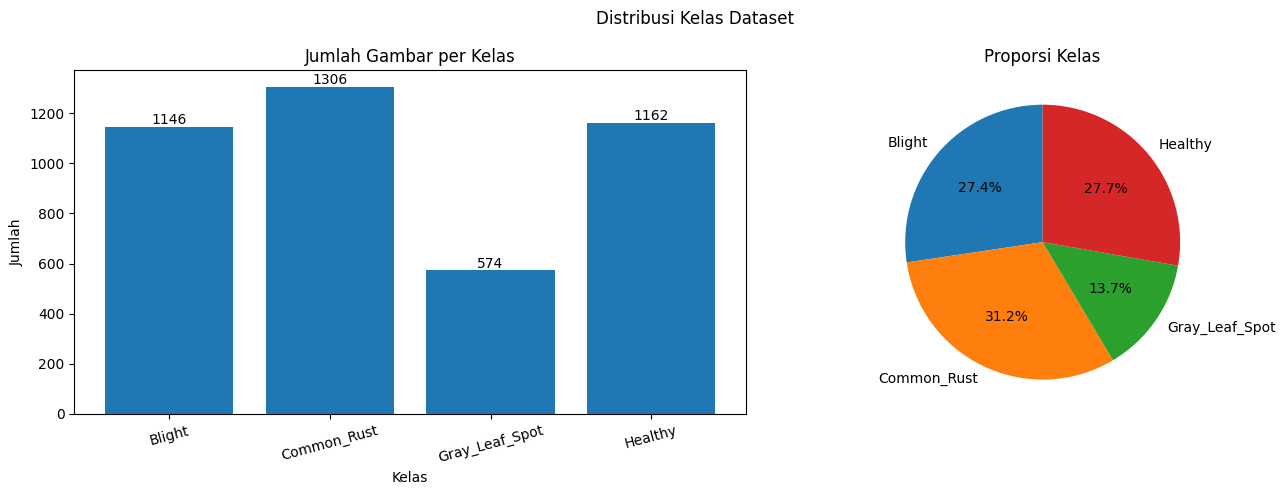

In [4]:
counts = df_meta['class_name'].value_counts().reindex(CLASS_NAMES)

fig, ax = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Distribusi Kelas Dataset')

# Bar chart
ax[0].bar(counts.index, counts.values)
ax[0].set(title='Jumlah Gambar per Kelas', xlabel='Kelas', ylabel='Jumlah')
ax[0].tick_params(axis='x', rotation=15)

for i, v in enumerate(counts.values):
    ax[0].text(i, v + 10, str(v), ha='center')

# Pie chart
ax[1].pie(counts.values, labels=counts.index, autopct='%1.1f%%', startangle=90)
ax[1].set_title('Proporsi Kelas')

plt.tight_layout()
plt.show()

Plot ini menunjukkan ketimpangan jumlah data (class imbalance), di mana kelas Common_Rust mendominasi sementara Gray_Leaf_Spot memiliki jumlah sampel yang jauh lebih sedikit. Perbedaan proporsi ini bisa menyebabkan model kesulitan mengenali ciri-ciri penyakit pada kelas minoritas tersebut

### A.3 Resolusi & Aspect Ratio

In [5]:
widths, heights, ratios = [], [], []

for path in df_meta['path']:
    try:
        w, h = Image.open(path).size
        widths.append(w)
        heights.append(h)
        ratios.append(w / h)
    except:
        continue  

df_meta['width'] = widths
df_meta['height'] = heights
df_meta['aspect_ratio'] = ratios

# Statistik
print('=== Statistik Resolusi ===')
print(f"Width  — min: {min(widths):.0f}  max: {max(widths):.0f}  mean: {np.mean(widths):.0f}")
print(f"Height — min: {min(heights):.0f}  max: {max(heights):.0f}  mean: {np.mean(heights):.0f}")
print(f"Aspect — min: {min(ratios):.3f}  max: {max(ratios):.3f}  mean: {np.mean(ratios):.3f}")

=== Statistik Resolusi ===
Width  — min: 180  max: 5184  mean: 308
Height — min: 116  max: 5184  mean: 298
Aspect — min: 0.288  max: 3.748  mean: 1.024


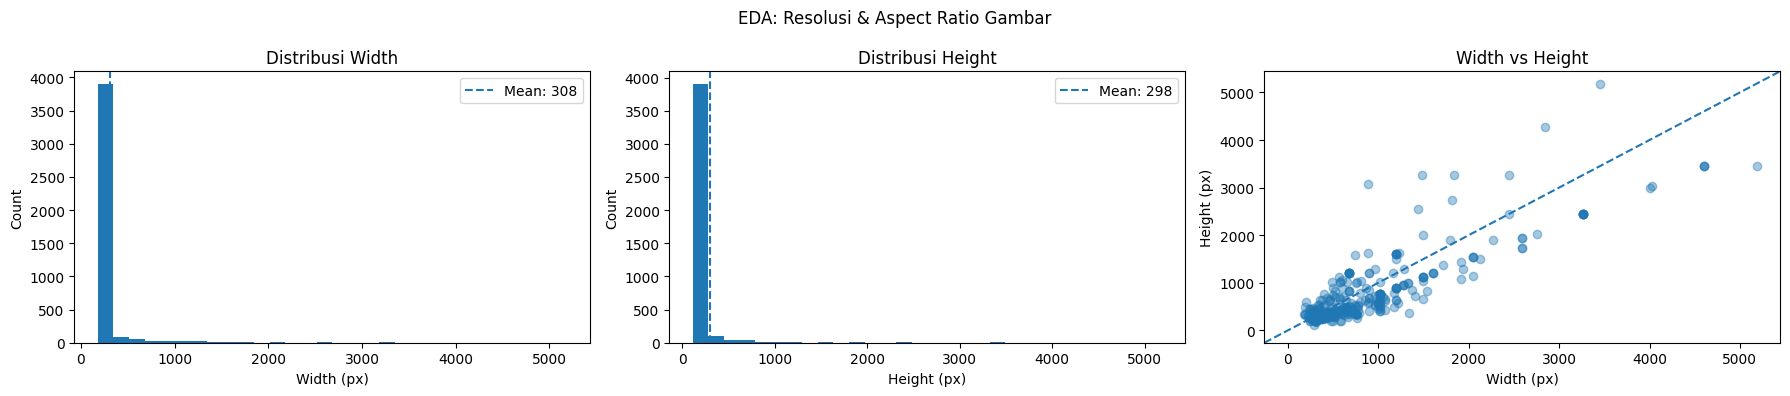

In [6]:
fig, ax = plt.subplots(1, 3, figsize=(18, 4))
fig.suptitle('EDA: Resolusi & Aspect Ratio Gambar')

# Width
ax[0].hist(df_meta['width'], bins=30)
ax[0].set(title='Distribusi Width', xlabel='Width (px)', ylabel='Count')
ax[0].axvline(df_meta['width'].mean(), ls='--', label=f"Mean: {df_meta['width'].mean():.0f}")
ax[0].legend()

# Height
ax[1].hist(df_meta['height'], bins=30)
ax[1].set(title='Distribusi Height', xlabel='Height (px)', ylabel='Count')
ax[1].axvline(df_meta['height'].mean(), ls='--', label=f"Mean: {df_meta['height'].mean():.0f}")
ax[1].legend()

# Scatter
ax[2].scatter(df_meta['width'], df_meta['height'], alpha=0.4)
ax[2].set(title='Width vs Height', xlabel='Width (px)', ylabel='Height (px)')
ax[2].axline((0, 0), slope=1, ls='--')

plt.tight_layout()
plt.show()

- Dominasi Resolusi Rendah: Mayoritas besar gambar dalam dataset terkonsentrasi pada resolusi rendah (di bawah 500 piksel). Hal ini dapat dilihat bar yang tinggi di bagian kiri plot (baik pada heigt, maupun width)

- Keberadaan Outlier: Ada beberapa sebaran data yang sangat luas hingga mencapai 5000+ piksel, namun jumlahnya sangat sedikit dibandingkan populasi utama.

- Karakteristik Aspek Rasio: Grafik scatter plot menunjukkan banyak gambar berada di sekitar garis diagonal, menandakan sebagian besar dataset memiliki aspek rasio mendekati 1:1

- Kebutuhan Standardisasi: Variasi ukuran yang ekstrem ini mengharuskan adanya proses resizing atau padding agar model dapat memproses data secara seragam tanpa kehilangan informasi penting.

### A.4 Sample Gambar

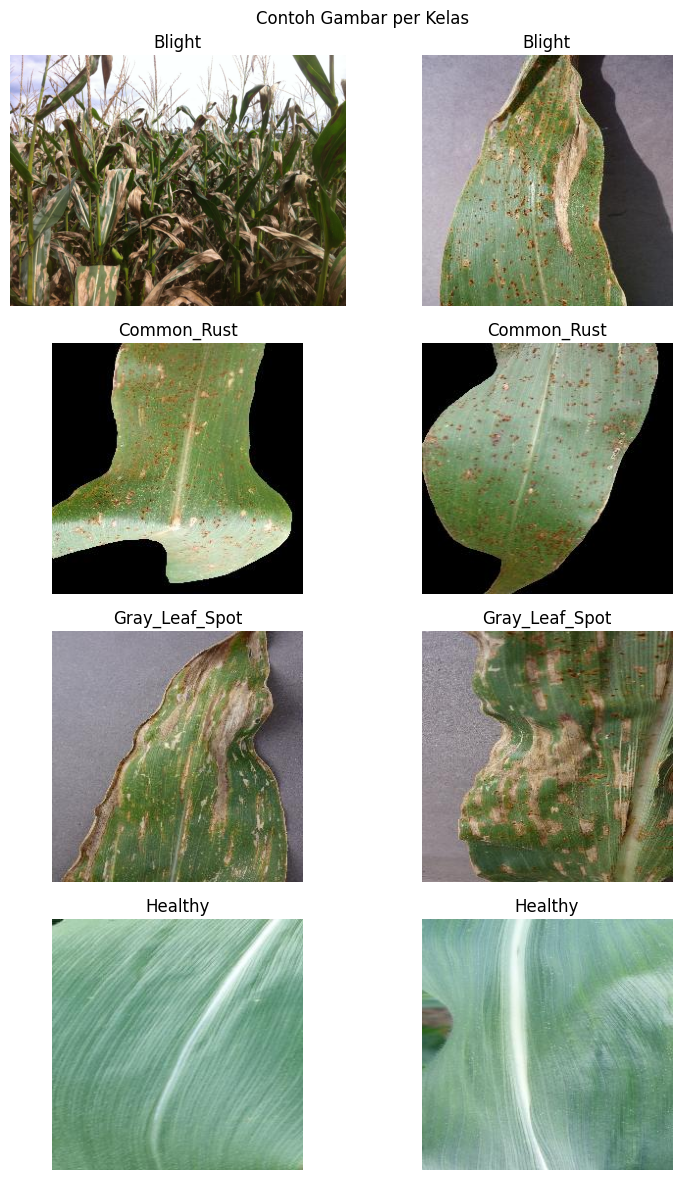

In [7]:
fig, ax = plt.subplots(len(CLASS_NAMES), 2, figsize=(8, 12))
fig.suptitle('Contoh Gambar per Kelas')

for i, cls in enumerate(CLASS_NAMES):
    samples = df_meta[df_meta['class_name'] == cls].sample(min(2, len(df_meta[df_meta['class_name'] == cls])))

    for j, path in enumerate(samples['path']):
        try:
            img = Image.open(path)
            ax[i, j].imshow(img)
        except:
            ax[i, j].text(0.5, 0.5, 'Error', ha='center', va='center')

        ax[i, j].set_title(cls)  
        ax[i, j].axis('off')

plt.tight_layout()
plt.show()

### A.5 Split Dataset
#### 70% Train | 15% Validation | 15% Test

In [8]:
paths = np.array(df_meta['path'])
labels = np.array(df_meta['label'])

# split 70 / 15 / 15
X_train, X_temp, y_train, y_temp = train_test_split(
    paths, labels, test_size=0.3, random_state=SEED, stratify=labels
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=SEED, stratify=y_temp
)

# ukuran data
total = len(paths)
print(f'Total : {total}')
print(f'Train : {len(X_train)}')
print(f'Val   : {len(X_val)}')
print(f'Test  : {len(X_test)}')

# distribusi kelas
print('\nDistribusi kelas:')
for name, y in [('Train', y_train), ('Val', y_val), ('Test', y_test)]:
    c = Counter(y)
    print(name, dict(c))

Total : 4188
Train : 2931
Val   : 628
Test  : 629

Distribusi kelas:
Train {np.int64(0): 802, np.int64(3): 813, np.int64(2): 402, np.int64(1): 914}
Val {np.int64(0): 172, np.int64(1): 196, np.int64(3): 174, np.int64(2): 86}
Test {np.int64(2): 86, np.int64(0): 172, np.int64(1): 196, np.int64(3): 175}


### A.6 Pre-processing & Data Generator

#### Load Dataset

In [9]:
def load_dataset(paths, labels, shuffle=False):
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    
    if shuffle:
        ds = ds.shuffle(len(paths), seed=SEED)
        
    return ds

#### Preprocessing

In [10]:
def preprocess(ds, img_size, batch_size, augment=False):

    def _process(path, label):
        img = tf.io.read_file(path)
        img = tf.image.decode_jpeg(img, channels=3) 

        img = tf.image.resize(img, img_size)
        
        img = tf.cast(img, tf.float32) / 255.0

        if augment:
            img = tf.image.random_flip_left_right(img)
            k = tf.random.uniform([], 0, 4, dtype=tf.int32)
            img = tf.image.rot90(img, k)
            img = tf.image.random_brightness(img, 0.1)
            img = tf.image.random_contrast(img, 0.9, 1.1)
            img = tf.clip_by_value(img, 0.0, 1.0)

        img.set_shape([img_size[0], img_size[1], 3])
        
        return img, label

    return (ds.map(_process, num_parallel_calls=tf.data.AUTOTUNE).batch(batch_size).prefetch(tf.data.AUTOTUNE))

- Decoding: Mengubah file gambar (.jpg) menjadi matriks angka agar dapat dibaca oleh model
- Resizing: Memaksa semua gambar menjadi ukuran 224x224 piksel agar input model sama
- Normalisasi: Mengubah skala warna dari 0-255 menjadi 0-1 agar perhitungan bobot model stabil
- Horizontal Flip: Membalik gambar secara acak (kiri ke kanan) untuk melatih model mengenali objek dari posisi berbeda
- Random Rotation: Memutar gambar 90, 180, atau 270 derajat agar model tidak kaku terhadap orientasi foto
- Brightness Adjustment: Mengubah kecerahan secara acak untuk mensimulasikan perbedaan kondisi cahaya saat pemotretan
- Contrast Adjustment: Memanipulasi kontras warna agar model tetap akurat meskipun kualitas kamera atau bayangan berubah
- Clipping: Memastikan nilai piksel hasil manipulasi tetap berada di rentang 0-1 agar tidak merusak data

In [11]:
train_ds = preprocess(
    load_dataset(X_train, y_train, shuffle=True),
    IMG_SIZE, BATCH_SIZE, augment=True
)

val_ds = preprocess(
    load_dataset(X_val, y_val),
    IMG_SIZE, BATCH_SIZE
)

test_ds = preprocess(
    load_dataset(X_test, y_test),
    IMG_SIZE, BATCH_SIZE
)

I0000 00:00:1776953501.364885      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1776953501.370867      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


In [12]:
print('Dataset siap:')
print(len(train_ds), len(val_ds), len(test_ds))

for x, y in train_ds.take(1):
    print(x.shape, y.shape)

Dataset siap:
92 20 20
(32, 224, 224, 3) (32,)


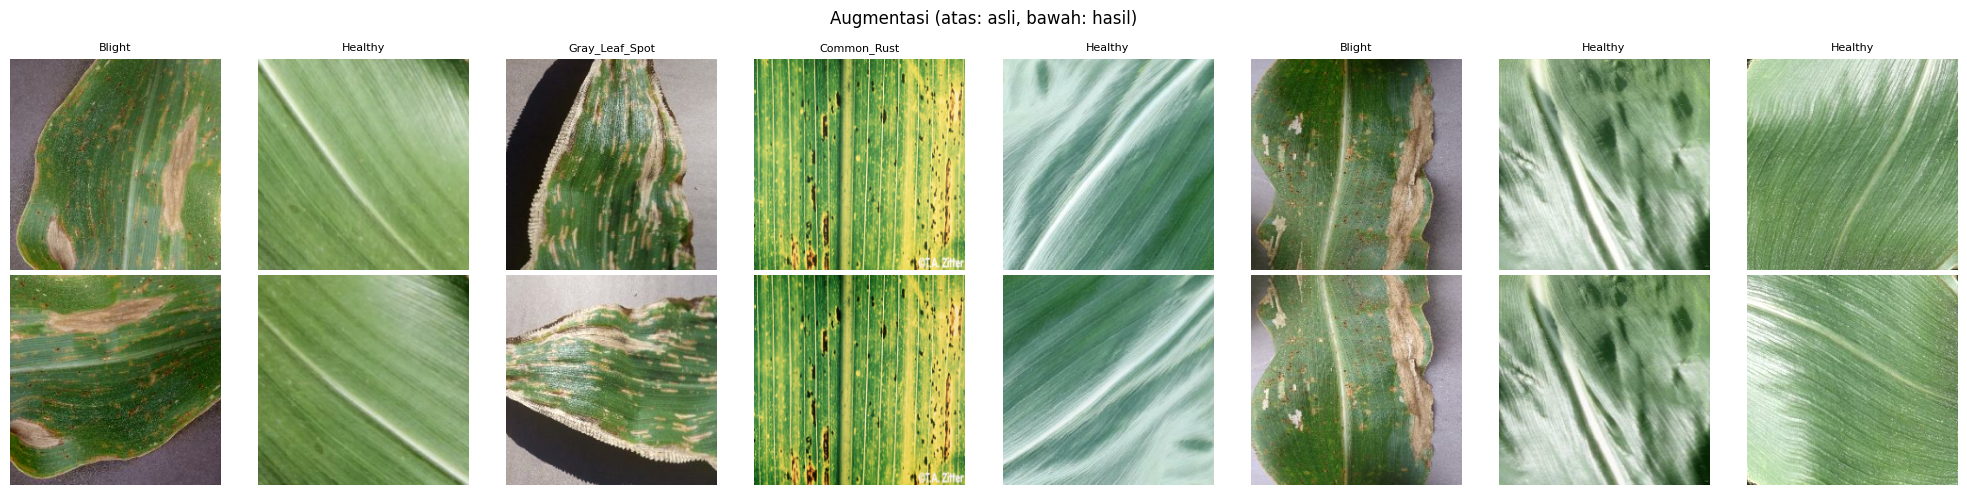

In [13]:
fig, ax = plt.subplots(2, 8, figsize=(20, 5))
fig.suptitle('Augmentasi (atas: asli, bawah: hasil)')

orig = preprocess(load_dataset(X_train[:8], y_train[:8]), IMG_SIZE, 8)
aug  = preprocess(load_dataset(X_train[:8], y_train[:8]), IMG_SIZE, 8, augment=True)

orig_imgs, orig_labels = next(iter(orig))
aug_imgs, _ = next(iter(aug))

for i in range(8):
    # original
    ax[0, i].imshow(orig_imgs[i])
    ax[0, i].set_title(CLASS_NAMES[int(orig_labels[i])], fontsize=8)
    ax[0, i].axis('off')

    # augmented
    ax[1, i].imshow(aug_imgs[i])
    ax[1, i].axis('off')

plt.tight_layout()
plt.show()


## B. Baseline Model: AlexNet

In [14]:
def build_alexnet_baseline(num_classes=4, input_shape=(224, 224, 3)):
    model = models.Sequential([
        layers.Input(shape=input_shape),

        layers.Conv2D(96, kernel_size=11, strides=4, padding='valid', activation='relu'),
        layers.MaxPooling2D(pool_size=3, strides=2),

        layers.Conv2D(256, kernel_size=5, padding='same', activation='relu'),
        layers.MaxPooling2D(pool_size=3, strides=2),

        layers.Conv2D(384, kernel_size=3, padding='same', activation='relu'),
        layers.Conv2D(384, kernel_size=3, padding='same', activation='relu'),
        layers.Conv2D(256, kernel_size=3, padding='same', activation='relu'),
        layers.MaxPooling2D(pool_size=3, strides=2),

        layers.Flatten(),
        
        layers.Dense(4096, activation='relu'),
        layers.Dropout(0.5),
        
        layers.Dense(4096, activation='relu'),
        layers.Dropout(0.5),

        layers.Dense(num_classes, activation='softmax')
    ], name='AlexNet_Baseline')

    return model

alexnet = build_alexnet_baseline(num_classes=NUM_CLASSES)

In [33]:
alexnet.summary()

Model: "AlexNet_Baseline"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 54, 54, 96)     │        34,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 26, 26, 96)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 26, 26, 256)    │       614,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 12, 12, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 12, 12, 384)    │       885,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 12, 12, 384)    │     1,327,488 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 12, 12, 256)    │       884,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 5, 5, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 6400)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 4096)           │    26,218,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4096)           │    16,781,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 4)              │        16,388 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 140,290,190 (535.16 MB)

 Trainable params: 46,763,396 (178.39 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 93,526,794 (356.78 MB)

In [15]:
alexnet.compile(
    optimizer=keras.optimizers.Adam(1e-4),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

cb_alexnet = [
    callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True),
    callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-7),
    callbacks.ModelCheckpoint('best_alexnet.keras', monitor='val_accuracy', save_best_only=True)
]

In [16]:
print(f'Training AlexNet Baseline — {EPOCHS_BASE} epoch maksimum...')

hist_alexnet = alexnet.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_BASE,
    callbacks=cb_alexnet
)

print(f'\nTraining selesai pada epoch: {len(hist_alexnet.history["loss"])}')

Training AlexNet Baseline — 30 epoch maksimum...
Epoch 1/30


I0000 00:00:1776953507.686198     130 service.cc:152] XLA service 0x7f85fc0087a0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1776953507.686246     130 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1776953507.686252     130 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1776953508.292382     130 cuda_dnn.cc:529] Loaded cuDNN version 91002


 3/92 ━━━━━━━━━━━━━━━━━━━━ 5s 60ms/step - accuracy: 0.3767 - loss: 1.3679 

I0000 00:00:1776953515.117287     130 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


92/92 ━━━━━━━━━━━━━━━━━━━━ 26s 176ms/step - accuracy: 0.4275 - loss: 1.2279 - val_accuracy: 0.5350 - val_loss: 0.8868 - learning_rate: 1.0000e-04
Epoch 2/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 8s 84ms/step - accuracy: 0.7187 - loss: 0.6831 - val_accuracy: 0.7723 - val_loss: 0.5365 - learning_rate: 1.0000e-04
Epoch 3/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 8s 87ms/step - accuracy: 0.7705 - loss: 0.5346 - val_accuracy: 0.8073 - val_loss: 0.4332 - learning_rate: 1.0000e-04
Epoch 4/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 5s 55ms/step - accuracy: 0.8014 - loss: 0.4862 - val_accuracy: 0.7978 - val_loss: 0.4655 - learning_rate: 1.0000e-04
Epoch 5/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 8s 83ms/step - accuracy: 0.8039 - loss: 0.4847 - val_accuracy: 0.8248 - val_loss: 0.3764 - learning_rate: 1.0000e-04
Epoch 6/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 8s 86ms/step - accuracy: 0.8228 - loss: 0.4306 - val_accuracy: 0.8439 - val_loss: 0.3570 - learning_rate: 1.0000e-04
Epoch 7/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 5s 55ms/step - accuracy: 0.8426 - loss: 0

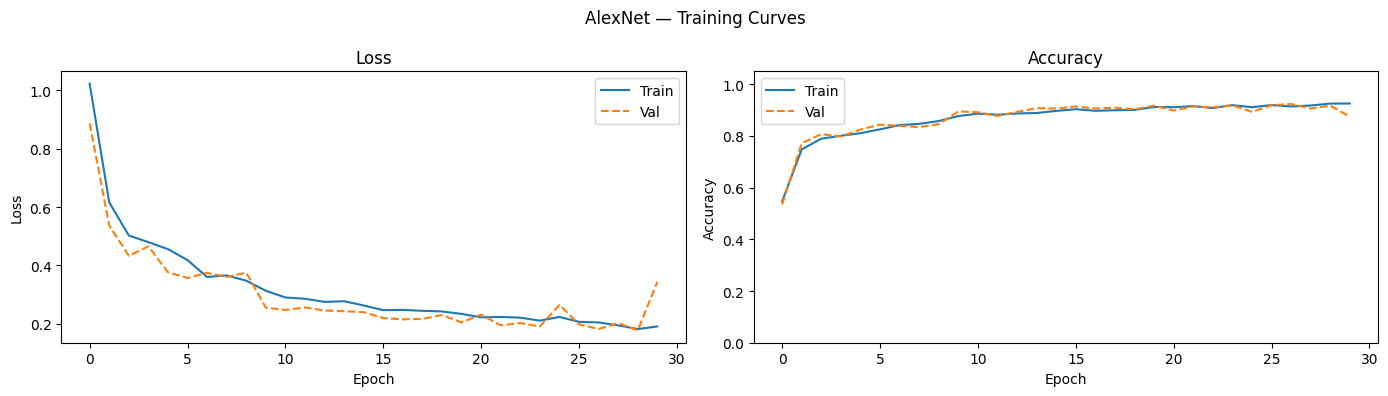

In [17]:
fig, ax = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle('AlexNet — Training Curves')

# Loss
ax[0].plot(hist_alexnet.history['loss'], label='Train')
ax[0].plot(hist_alexnet.history['val_loss'], '--', label='Val')
ax[0].set(title='Loss', xlabel='Epoch', ylabel='Loss')
ax[0].legend()

# Accuracy
ax[1].plot(hist_alexnet.history['accuracy'], label='Train')
ax[1].plot(hist_alexnet.history['val_accuracy'], '--', label='Val')
ax[1].set(title='Accuracy', xlabel='Epoch', ylabel='Accuracy')
ax[1].set_ylim(0, 1.05)
ax[1].legend()

plt.tight_layout()
plt.show()

**Interpretasi**
- Konvergensi: Model menunjukkan penurunan loss yang sangat tajam di awal dan berhasil mencapai titik stabil (plateau) di sekitar epoch ke-15 hingga ke-20, menandakan efisiensi dalam mempelajari pola data.

- Good Fit dan Generalisasi yang Kuat: Kurva Train dan Val bergerak beriringan secara konsisten dengan celah (gap) yang sangat minim, menunjukkan bahwa model memiliki kemampuan generalisasi yang sangat baik pada data baru

- Akurasi Tinggi: Model mencapai tingkat akurasi di atas 90% dengan fluktuasi yang rendah setelah melewati epoch ke-15, membuktikan bahwa arsitektur AlexNet ini telah menemukan bobot optimal untuk prediksi

- Anomali Akhir: Terdapat sedikit fluktuasi (lonjakan loss validasi) tepat di akhir epoch, namun secara keseluruhan model tetap mempertahankan performa yang stabil sepanjang proses pelatihan.

## C. Modified Model : AlexNet


| Komponen | Baseline | Modified | Alasan |
|---|---|---|---|
| Urutan layer Conv | `Conv + ReLU` | `Conv -> BN -> ReLU` | BN menormalisasi output Conv sebelum diaktivasi sehingga distribusi nilai lebih stabil dan gradien dapat mengalir lebih lancar ke layer sebelumnya selama backpropagation |
| Bias pada Conv | Ada | Dihapus (`use_bias=False`) | Parameter bias menjadi redundan karena Batch Normalization sudah memiliki parameter beta yang menjalankan fungsi identik sebagai offset, sehingga menghapusnya mengurangi parameter tanpa mengorbankan performa |
| Pooling sebelum Dense | `Flatten` | `GlobalAveragePooling2D` | Flatten menghasilkan 6.400 node yang disambung ke Dense(4096) menciptakan ~26 juta parameter hanya di satu layer, jauh melebihi jumlah data sehingga rawan overfitting, sedangkan GAP mereduksi output menjadi 256 node saja |
| Dense layer | 2× `Dense(4096)` | 1× `Dense(512)` | Kapasitas Dense(4096) dirancang untuk ImageNet dengan jutaan gambar, sedangkan dataset ini hanya ~4.100 gambar sehingga ukuran tersebut terlalu besar dan mendorong model menghafal data training alih-alih belajar fitur yang general |
| Jumlah hidden Dense | 2 layer | 1 layer | Dengan GAP yang sudah mengekstrak representasi spasial secara ringkas, satu Dense layer sudah cukup untuk melakukan klasifikasi sehingga mengurangi kompleksitas model dan memperkecil risiko overfitting |
| Class weight | Tidak ada | Ada (`balanced`) | Dataset mengalami class imbalance di mana Common_Rust jauh lebih dominan, sehingga tanpa class weight model cenderung mengabaikan kelas minoritas seperti Gray Leaf Spot yang terbukti dari recall-nya yang hanya 0.66 pada baseline |
| Max epoch | 30 | 50 | Batch Normalization dan class weight membuat proses konvergensi lebih lambat di awal training, sehingga epoch maksimum perlu ditambah agar model memiliki cukup waktu untuk mencapai performa optimalnya |

In [35]:
def build_modified_alexnet(num_classes=4, input_shape=(224, 224, 3)):
    model = models.Sequential([
        layers.Input(shape=input_shape),

        layers.Conv2D(96, kernel_size=11, strides=4, padding='valid', use_bias=False),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.MaxPooling2D(pool_size=3, strides=2),

        layers.Conv2D(256, kernel_size=5, padding='same', use_bias=False),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.MaxPooling2D(pool_size=3, strides=2),

        layers.Conv2D(384, kernel_size=3, padding='same', use_bias=False),
        layers.BatchNormalization(),
        layers.Activation('relu'),

        layers.Conv2D(384, kernel_size=3, padding='same', use_bias=False),
        layers.BatchNormalization(),
        layers.Activation('relu'),

        layers.Conv2D(256, kernel_size=3, padding='same', use_bias=False),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.MaxPooling2D(pool_size=3, strides=2),

        layers.GlobalAveragePooling2D(),
        
        layers.Dense(512, activation='relu'),
        layers.Dropout(0.5), 

        layers.Dense(num_classes, activation='softmax')
    ], name='Modified_AlexNet')

    return model

modified_alexnet = build_modified_alexnet(num_classes=4)

In [36]:
modified_alexnet.summary()

Model: "Modified_AlexNet"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_10 (Conv2D)              │ (None, 54, 54, 96)     │        34,848 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 54, 54, 96)     │           384 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_5 (Activation)       │ (None, 54, 54, 96)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 26, 26, 96)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 26, 26, 256)    │       614,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 26, 26, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_6 (Activation)       │ (None, 26, 26, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 12, 12, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 12, 12, 384)    │       884,736 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 12, 12, 384)    │         1,536 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_7 (Activation)       │ (None, 12, 12, 384)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 12, 12, 384)    │     1,327,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 12, 12, 384)    │         1,536 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_8 (Activation)       │ (None, 12, 12, 384)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 12, 12, 256)    │       884,736 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 12, 12, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_9 (Activation)       │ (None, 12, 12, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 5, 5, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 512)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 4)              │         2,05

 Total params: 3,884,964 (14.82 MB)

 Trainable params: 3,882,212 (14.81 MB)

 Non-trainable params: 2,752 (10.75 KB)

In [21]:
modified_alexnet.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-4),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

cb_modified = [
    callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True),
    callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-7),
    callbacks.ModelCheckpoint('best_modern_alexnet.keras', monitor='val_accuracy', save_best_only=True)
]

class_weights_array = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)

class_weights_dict = {i : class_weights_array[i] for i in range(len(class_weights_array))}

In [22]:
print(f'Training AlexNet (Modified) — {EPOCHS_MOD} epoch maksimum...')

hist_mod_alexnet = modified_alexnet.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_MOD,
    callbacks=cb_modified,
    class_weight=class_weights_dict
)

print(f'\nTraining selesai pada epoch: {len(hist_mod_alexnet.history["loss"])}')

Training AlexNet (Modified) — 50 epoch maksimum...
Epoch 1/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 20s 130ms/step - accuracy: 0.6691 - loss: 0.9024 - val_accuracy: 0.2771 - val_loss: 1.7108 - learning_rate: 1.0000e-04
Epoch 2/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 5s 55ms/step - accuracy: 0.8052 - loss: 0.5294 - val_accuracy: 0.3201 - val_loss: 2.1501 - learning_rate: 1.0000e-04
Epoch 3/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 5s 52ms/step - accuracy: 0.8279 - loss: 0.4622 - val_accuracy: 0.3742 - val_loss: 1.4341 - learning_rate: 1.0000e-04
Epoch 4/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 5s 51ms/step - accuracy: 0.8533 - loss: 0.3976 - val_accuracy: 0.4140 - val_loss: 1.9522 - learning_rate: 1.0000e-04
Epoch 5/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 5s 53ms/step - accuracy: 0.8652 - loss: 0.3710 - val_accuracy: 0.5525 - val_loss: 1.8153 - learning_rate: 1.0000e-04
Epoch 6/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 5s 52ms/step - accuracy: 0.8878 - loss: 0.3138 - val_accuracy: 0.8217 - val_loss: 0.7650 - learning_rate: 1.0000e-04
Epoch 7/50
92/92 

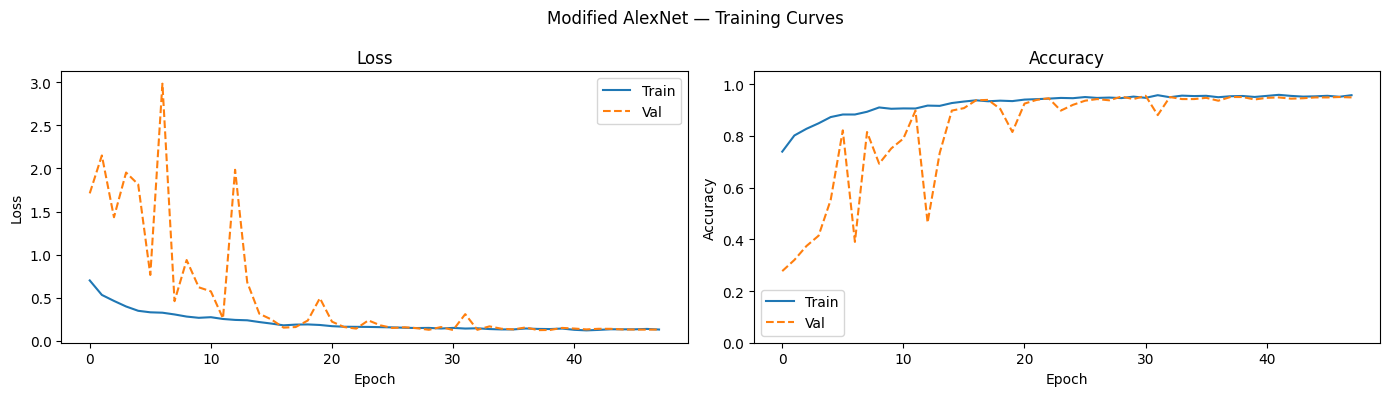

In [23]:
fig, ax = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle('Modified AlexNet — Training Curves')

# Loss
ax[0].plot(hist_mod_alexnet.history['loss'], label='Train')
ax[0].plot(hist_mod_alexnet.history['val_loss'], '--', label='Val')
ax[0].set(title='Loss', xlabel='Epoch', ylabel='Loss')
ax[0].legend()

# Accuracy
ax[1].plot(hist_mod_alexnet.history['accuracy'], label='Train')
ax[1].plot(hist_mod_alexnet.history['val_accuracy'], '--', label='Val')
ax[1].set(title='Accuracy', xlabel='Epoch', ylabel='Accuracy')
ax[1].set_ylim(0, 1.05)
ax[1].legend()

plt.tight_layout()
plt.show()

**Interpretasi**

- Konvergensi Bertahap: Meskipun kurva validasi mengalami fluktuasi yang sangat tajam di awal pelatihan (hingga epoch ke-20), model berhasil mencapai titik stabil (plateau) di sekitar epoch ke-35 dengan nilai loss yang sangat rendah.

- Good Fit dan Generalisasi Tinggi: Setelah melewati fase yang tidak stabil di awal, kurva Train dan Val akhirnya berhimpit dengan sangat rapat. Hal ini menunjukkan bahwa model berhasil mengatasi kesulitan belajar di awal dan mencapai kemampuan generalisasi yang sangat kuat tanpa indikasi overfitting.

- Stabilitas dan Akurasi: Di akhir pelatihan (epoch 35-48), akurasi model mencapai puncaknya di atas 90% dengan kondisi yang sangat stabil. Ini membuktikan bahwa modifikasi pada arsitektur ini sangat efektif dalam menghasilkan prediksi yang akurat dan konsisten.

## D. Evaluation on Test Data


In [24]:
def get_predictions(model, dataset):
    y_true = np.concatenate([y for x, y in dataset], axis=0)
    y_pred = np.argmax(model.predict(dataset, verbose=0), axis=1)
    return y_true, y_pred

y_true_base, y_pred_base = get_predictions(alexnet, test_ds)
y_true_mod, y_pred_mod   = get_predictions(modified_alexnet, test_ds)

#### Model Comparison 

In [25]:
def calc_metrics(y_true, y_pred, name):
    return {
        'Model': name,
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred, average='macro', zero_division=0),
        'Recall': recall_score(y_true, y_pred, average='macro', zero_division=0),
        'F1-Score': f1_score(y_true, y_pred, average='macro', zero_division=0)
    }

df_metrics = pd.DataFrame([
    calc_metrics(y_true_base, y_pred_base, 'AlexNet Baseline'),
    calc_metrics(y_true_mod, y_pred_mod, 'AlexNet Modified')]).set_index('Model')

display(df_metrics.style.format('{:.4f}'))

,Accuracy,Precision,Recall,F1-Score
Model,,,,
AlexNet Baseline,0.9237,0.9159,0.8899,0.8986
AlexNet Modified,0.9587,0.9438,0.9527,0.9478


In [26]:
print('\nClassification Report — AlexNet Baseline')
print(classification_report(y_true_base, y_pred_base, target_names=CLASS_NAMES))


Classification Report — AlexNet Baseline
                precision    recall  f1-score   support

        Blight       0.83      0.95      0.89       172
   Common_Rust       0.97      0.95      0.96       196
Gray_Leaf_Spot       0.86      0.66      0.75        86
       Healthy       0.99      1.00      1.00       175

      accuracy                           0.92       629
     macro avg       0.92      0.89      0.90       629
  weighted avg       0.93      0.92      0.92       629



In [27]:
print('\nClassification Report — AlexNet Modified')
print(classification_report(y_true_mod, y_pred_mod, target_names=CLASS_NAMES))


Classification Report — AlexNet Modified
                precision    recall  f1-score   support

        Blight       0.95      0.91      0.93       172
   Common_Rust       0.99      0.98      0.99       196
Gray_Leaf_Spot       0.84      0.92      0.88        86
       Healthy       0.99      1.00      1.00       175

      accuracy                           0.96       629
     macro avg       0.94      0.95      0.95       629
  weighted avg       0.96      0.96      0.96       629



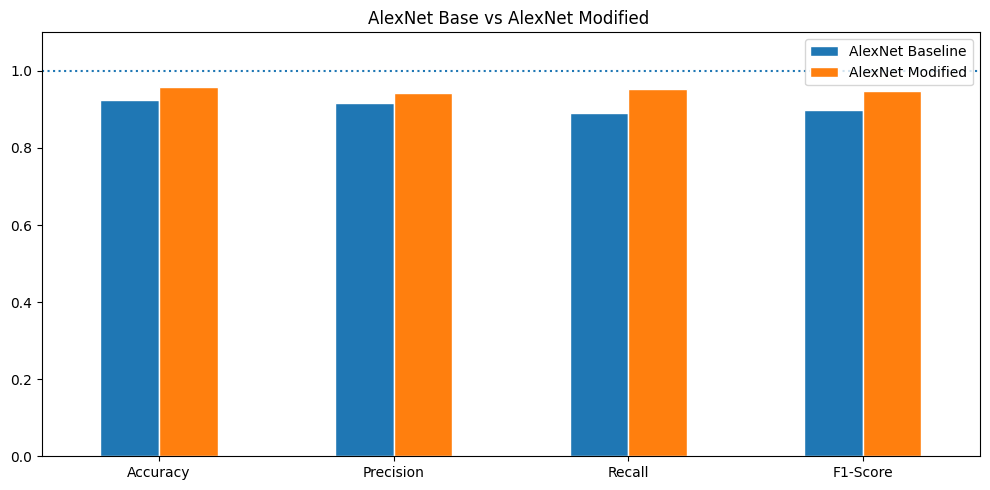

In [31]:
df_metrics.T.plot(kind='bar', figsize=(10, 5), edgecolor='white')
plt.title('AlexNet Base vs AlexNet Modified ')
plt.ylim(0, 1.1)
plt.xticks(rotation=0)
plt.axhline(1.0, ls=':')
plt.legend()
plt.tight_layout()
plt.show()

**Interpretasi Perbandingan Model**

- Peningkatan Akurasi Keseluruhan: Akurasi meningkat dari 0.92 (92%) pada model baseline menjadi 0.96 (96%) pada model modified. Hal ini menunjukkan bahwa perubahan arsitektur model berhasil meningkatkan kemampuan model dalam melakukan klasifikasi secara umum

- Optimalisasi Kelas Minoritas (Gray Leaf Spot): Pada model baseline, kelas ini memiliki nilai recall yang relatif rendah (0.66), yang mengindikasikan masih banyak data positif yang tidak terdeteksi. Setelah dilakukan modifikasi, recall meningkat signifikan menjadi 0.92. Peningkatan ini kemungkinan besar dipengaruhi oleh penggunaan class weight, yang membantu model memberikan perhatian lebih pada kelas minoritas sehingga sensitivitas terhadap kelas tersebut meningkat.

- Keseimbangan Presisi dan Recall: Nilai F1-score pada hampir seluruh kelas mengalami peningkatan, terutama pada kelas Blight dan Gray Leaf Spot. Hal ini menunjukkan bahwa model hasil modifikasi lebih seimbang dalam menangani false positive dan false negative. Selain itu, penggunaan class weight juga berkontribusi dalam meningkatkan keseimbangan ini, karena membantu mengurangi bias model terhadap kelas mayoritas.

#### Confusion Matrix

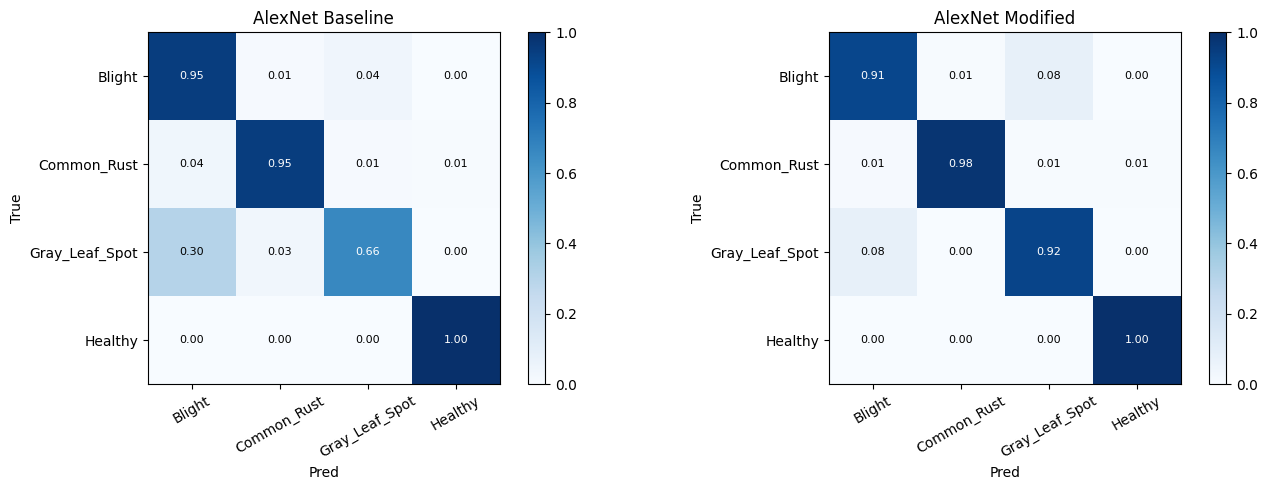

In [32]:
def plot_cm(y_true, y_pred, title, ax, cmap='Blues'):
    cm = confusion_matrix(y_true, y_pred)
    cm = cm / cm.sum(axis=1, keepdims=True)

    im = ax.imshow(cm, cmap=cmap, vmin=0, vmax=1)
    ax.set_title(title)
    ax.set_xticks(range(NUM_CLASSES))
    ax.set_yticks(range(NUM_CLASSES))
    ax.set_xticklabels(CLASS_NAMES, rotation=30)
    ax.set_yticklabels(CLASS_NAMES)
    ax.set_xlabel('Pred')
    ax.set_ylabel('True')

    for i in range(NUM_CLASSES):
        for j in range(NUM_CLASSES):
            ax.text(j, i, f'{cm[i,j]:.2f}', ha='center', va='center',
                    color='white' if cm[i,j] > 0.5 else 'black', fontsize=8)

    plt.colorbar(im, ax=ax)


fig, ax = plt.subplots(1, 2, figsize=(14, 5))
plot_cm(y_true_base, y_pred_base, 'AlexNet Baseline', ax[0])
plot_cm(y_true_mod, y_pred_mod, 'AlexNet Modified', ax[1])
plt.tight_layout()
plt.show()

- Perbaikan pada Kelas Minoritas: Kelas Gray Leaf Spot mengalami peningkatan yang signifikan. Kesalahan klasifikasi turun dari 30% menjadi 8%, sehingga akurasi prediksi kelas tersebut naik dari 0.66 ke 0.92.
- Akurasi Lebih Konsisten: Modified menunjukkan nilai diagonal (true positive) yang lebih tinggi dan merata, menandakan prediksi lebih stabil di semua kelas.
- Deteksi Kelas Sehat Stabil: Kedua model mencapai akurasi 1.00 pada kelas Healthy, sehingga tidak terjadi kesalahan diagnosis pada tanaman sehat.

#### Sample dari Kesalahan Model (Modified)

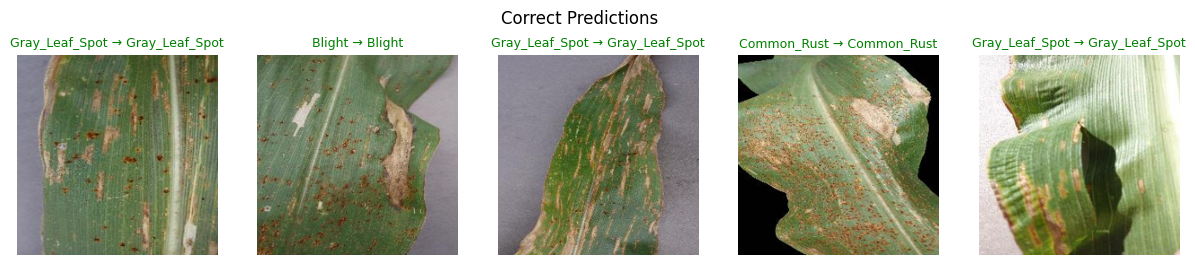

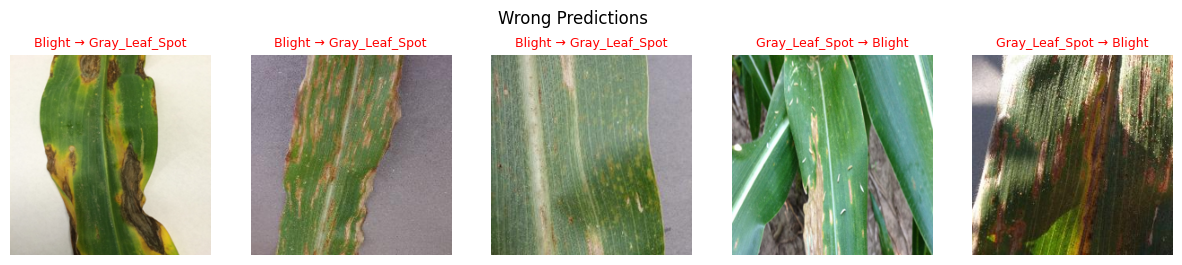

In [30]:
def show_samples(paths, y_true, y_pred, correct=True, n=5, title=''):
    idx = np.where((y_true == y_pred) if correct else (y_true != y_pred))[0][:n]

    if len(idx) == 0:
        print('No samples found')
        return

    fig, ax = plt.subplots(1, len(idx), figsize=(15, 3))
    fig.suptitle(title)

    if len(idx) == 1:
        ax = [ax]

    for a, i in zip(ax, idx):
        img = Image.open(paths[i]).resize(IMG_SIZE)
        a.imshow(img)
        a.axis('off')
        a.set_title(f"{CLASS_NAMES[y_true[i]]} → {CLASS_NAMES[y_pred[i]]}",color='green' if correct else 'red', fontsize=9)

    plt.show()


show_samples(X_test, y_true_mod, y_pred_mod, True, title='Correct Predictions')
show_samples(X_test, y_true_mod, y_pred_mod, False, title='Wrong Predictions')

**Saran Pengembangan Lebih Lanjut**

1. Augmentasi Data yang Lebih Terarah (Targeted Augmentation)

Augmentasi data tambahan bisa dilakukan bukan secara asal, tetapi berdasarkan karakterisik gambar pada kelas yang sulit dibedakan misalnya Blight dan Gray Leaf Spot. Teknik seperti CutMix atau Mixup membantu model memahami batas antar kelas dengan lebih baik,selain itu, color jittering bisa menyesuaikan variasi warna yang menjadi ciri penting pada penyakit daun.

2. Hyperparameter Tuning (Automated Search)

Dengan memanfaatkan tools seperti Optuna atau Keras Tuner, model dapat secara otomatis mencari kombinasi terbaik dari parameter seperti learning rate, dropout rate, dan weight decay. Pendekatan ini membantu mengurangi fluktuasi pada validation loss serta memungkinkan model mencapai konvergensi yang lebih stabil dan mendekati solusi optimal

3. Implementasi Ensemble Model

Jika satu model belum memberikan hasil optimal, pendekatan ensemble dapat digunakan dengan menggabungkan beberapa arsitektur seperti EfficientNet, ResNet, dan DenseNet. Setiap model memiliki keunggulan berbeda dalam menangkap pola, sehingga kombinasi prediksi melalui metode seperti voting atau weighted averaging dapat menyeimbangkan kesalahan individu. Dengan cara ini, jika satu model keliru dalam mengklasifikasikan suatu kelas, model lain dapat mengoreksi, sehingga hasil akhir menjadi lebih stabil dan akurat.